C:\Users\asdxo\AppData\Local\Temp\ipykernel_3924\3694658512.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_report, x='price_range', y='중앙값_흥행_규모', ax=ax1, palette='Blues_d', alpha=0.7)


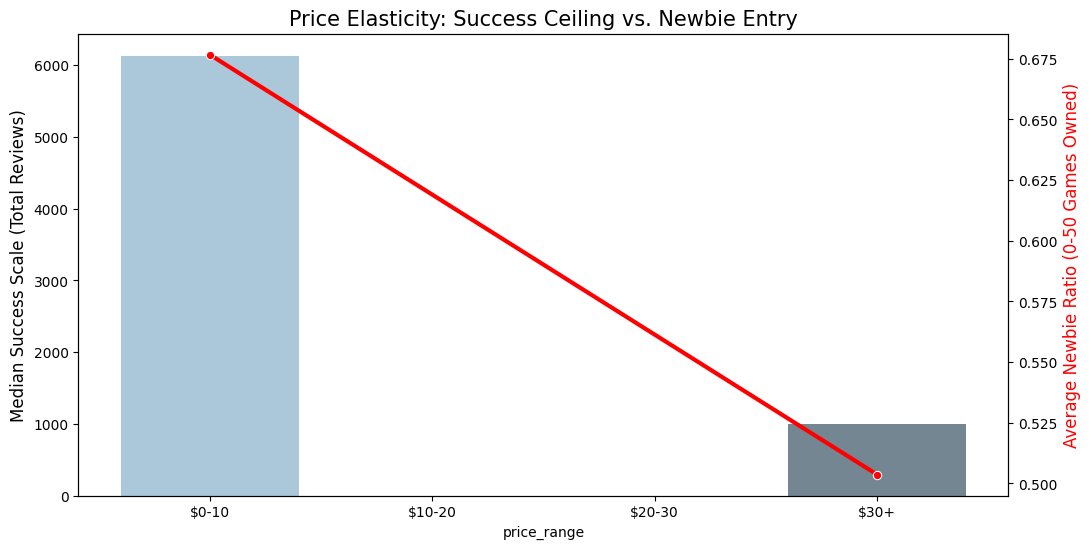


가격 구간별 흥행 성적표


,price_range,게임_수,평균_흥행_규모,중앙값_흥행_규모,평균_뉴비_비율
0,$0-10,3,24084.667,6132.0,0.677
1,$10-20,0,NaN,NaN,NaN
2,$20-30,0,NaN,NaN,NaN
3,$30+,70,7122.586,998.0,0.504


: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 74개 정예 필터링
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 정예 게임 추출 (stratum 활용)
target_strata = ['large_high', 'mid_high', 'small_high']
df_high = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 가격 데이터 정제 (price_spy -> price_usd 변환 및 0원 방지)
if 'price_spy' in df_high.columns:
    df_high['price_usd'] = df_high['price_spy'] * 100
df_high['price_usd'] = df_high['price_usd'].replace(0, 0.99) # 무료 게임도 최소값 처리

# 2. 가격 구간(Price Bin) 설정
# 인디 게임 시장의 일반적인 가격 심리선에 따라 나눕니다.
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df_high['price_range'] = pd.cut(df_high['price_usd'], bins=bins, labels=labels)

# 3. 뉴비 유입 비율 계산
# 뉴비 정의: 보유 게임 수 50개 이하 (유저님 이전 분석 기준 적용)
df_merged = pd.merge(df_reviews, df_high[['appid', 'price_range']], on='appid')
df_merged['is_newbie'] = df_merged['author_num_games_owned'] <= 50

newbie_ratio = df_merged.groupby('appid')['is_newbie'].mean().reset_index(name='newbie_ratio')
df_analysis = pd.merge(df_high, newbie_ratio, on='appid')

# 4. 가격 구간별 최종 흥행 규모 및 뉴비 비율 집계
price_report = df_analysis.groupby('price_range', observed=False).agg(
    게임_수=('appid', 'count'),
    평균_흥행_규모=('total_reviews', 'mean'),
    중앙값_흥행_규모=('total_reviews', 'median'),
    평균_뉴비_비율=('newbie_ratio', 'mean')
).reset_index()

# 5. 시각화: 가격 구간별 흥행 천장 및 뉴비 유입 상관관계
fig, ax1 = plt.subplots(figsize=(12, 6))

# 바 차트: 흥행 규모 (중앙값 기준)
sns.barplot(data=price_report, x='price_range', y='중앙값_흥행_규모', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('Median Success Scale (Total Reviews)', fontsize=12)
ax1.set_title('Price Elasticity: Success Ceiling vs. Newbie Entry', fontsize=15)

# 라인 차트: 뉴비 비율 (우측 Y축)
ax2 = ax1.twinx()
sns.lineplot(data=price_report, x='price_range', y='평균_뉴비_비율', ax=ax2, color='red', marker='o', linewidth=3)
ax2.set_ylabel('Average Newbie Ratio (0-50 Games Owned)', color='red', fontsize=12)

plt.show()

print("\n" + "="*70)
print("가격 구간별 흥행 성적표")
print("="*70)
display(price_report.round(3))
print("="*70)